# DenseNet121 v2 — CBIS-DDSM Cropped Images (Record-Breaking Edition)

**Improvements over the previous notebook:**
1. **Higher input resolution** 320×320 (was 224×224) — finer mammographic detail.
2. **Stronger head** — concatenated GAP+GMP, deeper MLP with swish, BN+Dropout.
3. **Stronger augmentations** — flips, zoom, brightness/contrast, gaussian noise, **Cutout**, **MixUp**, **CutMix**.
4. **Focal loss + label smoothing** — better for imbalanced + reduces overconfidence.
5. **AdamW + Warmup + Cosine LR schedule** — much better convergence than ReduceLROnPlateau.
6. **Discriminative learning rates** — backbone learns slower than head during fine-tuning.
7. **Progressive unfreezing** in Phase 2 (last 120 conv layers, BN kept frozen).
8. **Test-Time Augmentation (TTA)** — 8× augmented predictions averaged.
9. **Threshold optimization** — Youden's J + F1-max + cost-balanced.
10. **Improved Grad-CAM** with proper malignant/benign comparison.

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 ── Install + verify GPU + enable mixed precision + mount Drive
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

!pip install -q scikit-learn matplotlib seaborn opencv-python-headless

import tensorflow as tf
print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Compute policy:", mixed_precision.global_policy().name)

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute policy: mixed_float16
Mounted at /content/drive


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 ── Configuration  ← only edit this cell
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import os, math, random, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score,
    precision_recall_curve, average_precision_score,
)
from tensorflow.keras import layers, Model, callbacks, optimizers, regularizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# ── Paths ────────────────────────────────────────────────────────────────
JPEG_BASE  = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/jpeg")
CSV_DIR    = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/csv")
OUTPUT_DIR = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split")

SPLIT_DIR = OUTPUT_DIR
TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"

SAVE_DIR = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Image / batch settings ───────────────────────────────────────────────
IMG_SIZE     = 320   # ↑ from 224 — captures finer mammographic detail
RESIZE_SIZE  = 360   # decode to 360, then random-crop to 320 in training
CHANNELS     = 3
BATCH_SIZE   = 24    # T4 fits ~24 at 320×320 with mixed-precision

# ── Training schedule ────────────────────────────────────────────────────
PHASE1_EPOCHS  = 12   # head only — frozen backbone
PHASE2_EPOCHS  = 35   # progressive fine-tune (last 120 layers)
WARMUP_EPOCHS  = 3    # linear warmup → cosine

PHASE1_BASE_LR = 1e-3
PHASE2_BASE_LR = 5e-5   # global Phase-2 LR (cosine + warmup → tiny tail)
WEIGHT_DECAY   = 1e-4

# Regularization
DROPOUT_RATE = 0.5
L2_REG       = 1e-5

# Loss
FOCAL_GAMMA      = 2.0
LABEL_SMOOTHING  = 0.05

# Augmentation strengths
MIXUP_ALPHA   = 0.2
CUTMIX_ALPHA  = 1.0
MIX_PROB      = 0.5    # 50 % MixUp, 30 % CutMix, 20 % no-mix
CUTMIX_PROB   = 0.3
CUTOUT_SIZE   = 48     # px erased patch in training

# Fine-tuning policy
UNFREEZE_LAYERS = 120   # last N backbone layers unfrozen in Phase 2

# TTA
TTA_STEPS = 8

# Reproducibility
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

print("=" * 70)
print("  DenseNet121 v2 — Breast Cancer Classification (record-breaking)")
print("=" * 70)
print(f"  Split dir   : {SPLIT_DIR}")
print(f"  Save dir    : {SAVE_DIR}")
print(f"  Image size  : {IMG_SIZE}×{IMG_SIZE}×{CHANNELS}")
print(f"  Resize size : {RESIZE_SIZE}×{RESIZE_SIZE}  (crop to {IMG_SIZE} in train)")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Phase 1     : {PHASE1_EPOCHS} epochs  base_lr={PHASE1_BASE_LR}")
print(f"  Phase 2     : {PHASE2_EPOCHS} epochs  base_lr={PHASE2_BASE_LR}  warmup={WARMUP_EPOCHS} ep")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Loss        : Focal-BCE  γ={FOCAL_GAMMA}  label-smooth={LABEL_SMOOTHING}")
print(f"  MixUp α={MIXUP_ALPHA}  CutMix α={CUTMIX_ALPHA}  TTA-steps={TTA_STEPS}")

  DenseNet121 v2 — Breast Cancer Classification (record-breaking)
  Split dir   : /content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split
  Save dir    : /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v2
  Image size  : 320×320×3
  Resize size : 360×360  (crop to 320 in train)
  Batch size  : 24
  Phase 1     : 12 epochs  base_lr=0.001
  Phase 2     : 35 epochs  base_lr=5e-05  warmup=3 ep
  Weight decay: 0.0001
  Loss        : Focal-BCE  γ=2.0  label-smooth=0.05
  MixUp α=0.2  CutMix α=1.0  TTA-steps=8


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 ── Dataset inspection + class-weight calculation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("▶  STEP 1 — Dataset inspection …\n")

stats = {}
for split in ["train", "val", "test"]:
    sp = SPLIT_DIR / split
    counts = {}
    for label in ["malignant", "benign"]:
        p = sp / label
        counts[label] = (
            len(list(p.glob("*.jpg")) + list(p.glob("*.jpeg")) + list(p.glob("*.png")))
            if p.exists() else 0
        )
    stats[split] = counts

print(f"  {'Split':<8} {'Malignant':>10} {'Benign':>8} {'Total':>7}  Mal%")
print(f"  {'─'*42}")
for split, cnt in stats.items():
    mal, ben = cnt["malignant"], cnt["benign"]
    total    = mal + ben
    pct      = mal / total * 100 if total > 0 else 0.0
    print(f"  {split:<8} {mal:>10,} {ben:>8,} {total:>7,}  {pct:.1f}%")

n_mal   = stats["train"]["malignant"]
n_ben   = stats["train"]["benign"]
n_total = n_mal + n_ben

w_mal = n_total / (2 * n_mal)
w_ben = n_total / (2 * n_ben)
CLASS_WEIGHTS = {0: w_ben, 1: w_mal}

print(f"\n  Class weights:  benign(0)→{w_ben:.4f}   malignant(1)→{w_mal:.4f}")
print("  These are used as a backup signal alongside focal loss.")

▶  STEP 1 — Dataset inspection …

  Split     Malignant   Benign   Total  Mal%
  ──────────────────────────────────────────
  train         1,004    1,472   2,476  40.5%
  val             231      340     571  40.5%
  test            215      287     502  42.8%

  Class weights:  benign(0)→0.8410   malignant(1)→1.2331
  These are used as a backup signal alongside focal loss.


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 ── Preprocessing & augmentation pipelines
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("▶  STEP 2 — Building preprocessing & augmentation pipelines …\n")

# ── CLAHE (run in numpy via tf.py_function) ──────────────────────────────
def apply_clahe(image_np: np.ndarray) -> np.ndarray:
    """Apply CLAHE to a uint8 image. RGB → LAB → equalize L → RGB."""
    if image_np.ndim == 2 or image_np.shape[2] == 1:
        img_u8    = image_np.squeeze().astype(np.uint8)
        clahe     = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        equalized = clahe.apply(img_u8)
        return np.stack([equalized] * 3, axis=-1)
    lab     = cv2.cvtColor(image_np.astype(np.uint8), cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l_eq    = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2RGB)


def _decode_resize_clahe(image_path, size):
    raw   = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(raw, channels=CHANNELS)
    image = tf.image.resize(image, [size, size], method="bilinear")
    image = tf.cast(image, tf.uint8)
    image = tf.py_function(
        func = lambda img: apply_clahe(img.numpy()),
        inp  = [image], Tout = tf.uint8,
    )
    image.set_shape([size, size, 3])
    return tf.cast(image, tf.float32)


# ── Per-image cutout ──────────────────────────────────────────────────────
def random_cutout(image, size=CUTOUT_SIZE):
    """Erase a random square (replace with zero ≈ image mean after preprocess)."""
    H = tf.shape(image)[0]
    W = tf.shape(image)[1]
    cy = tf.random.uniform([], 0, H, dtype=tf.int32)
    cx = tf.random.uniform([], 0, W, dtype=tf.int32)
    half = size // 2
    y1 = tf.maximum(0, cy - half); y2 = tf.minimum(H, cy + half)
    x1 = tf.maximum(0, cx - half); x2 = tf.minimum(W, cx + half)
    yy = tf.range(H)[:, None]
    xx = tf.range(W)[None, :]
    mask = (yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2)
    mask = tf.cast(mask, image.dtype)[..., None]   # 1 inside cutout
    return image * (1.0 - mask)


# ── Per-image preprocessing: TRAIN ────────────────────────────────────────
def preprocess_image_train(image_path, label):
    image = _decode_resize_clahe(image_path, RESIZE_SIZE)
    # random crop to IMG_SIZE
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
    # flips
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    # brightness / contrast jitter
    image = tf.image.random_brightness(image, max_delta=0.15 * 255.0)
    image = tf.image.random_contrast(image,   lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 255.0)
    # normalize via DenseNet (ImageNet stats → roughly [-1, 1])
    image = preprocess_input(image)
    # gaussian noise (after normalize)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise
    # random cutout (50 % chance)
    do_cut = tf.random.uniform([], 0.0, 1.0) < 0.5
    image  = tf.cond(do_cut, lambda: random_cutout(image), lambda: image)
    image  = tf.clip_by_value(image, -2.5, 2.5)
    label  = tf.cast(label, tf.float32)
    return image, label


# ── Per-image preprocessing: VAL / TEST  (center-crop, no aug) ───────────
def preprocess_image_val(image_path, label):
    image = _decode_resize_clahe(image_path, RESIZE_SIZE)
    # center crop
    off = (RESIZE_SIZE - IMG_SIZE) // 2
    image = image[off:off + IMG_SIZE, off:off + IMG_SIZE, :]
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    image = preprocess_input(image)
    label = tf.cast(label, tf.float32)
    return image, label


# ── Per-image preprocessing: TTA  (8 augmentations applied at test) ──────
def make_tta_view(image_path, label, tta_id):
    """Deterministic geometric variant for TTA. tta_id ∈ [0..7]."""
    image = _decode_resize_clahe(image_path, RESIZE_SIZE)
    off = (RESIZE_SIZE - IMG_SIZE) // 2
    image = image[off:off + IMG_SIZE, off:off + IMG_SIZE, :]
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    # 0:none  1:hflip  2:vflip  3:hvflip  4:rot90  5:rot180  6:rot270  7:hflip+rot90
    def apply_tta(img, t):
        img = tf.cond(tf.equal(t, 1), lambda: tf.image.flip_left_right(img), lambda: img)
        img = tf.cond(tf.equal(t, 2), lambda: tf.image.flip_up_down(img),    lambda: img)
        img = tf.cond(tf.equal(t, 3),
                      lambda: tf.image.flip_up_down(tf.image.flip_left_right(img)),
                      lambda: img)
        img = tf.cond(tf.equal(t, 4), lambda: tf.image.rot90(img, k=1), lambda: img)
        img = tf.cond(tf.equal(t, 5), lambda: tf.image.rot90(img, k=2), lambda: img)
        img = tf.cond(tf.equal(t, 6), lambda: tf.image.rot90(img, k=3), lambda: img)
        img = tf.cond(tf.equal(t, 7),
                      lambda: tf.image.rot90(tf.image.flip_left_right(img), k=1),
                      lambda: img)
        return img
    image = apply_tta(image, tta_id)
    image = preprocess_input(image)
    label = tf.cast(label, tf.float32)
    return image, label


# ── Batch-level MixUp / CutMix ────────────────────────────────────────────
def _sample_beta(alpha):
    g1 = tf.random.gamma([], alpha)
    g2 = tf.random.gamma([], alpha)
    return g1 / (g1 + g2 + 1e-8)

def mixup(images, labels, alpha=MIXUP_ALPHA):
    bs   = tf.shape(images)[0]
    lam  = _sample_beta(alpha)
    lam  = tf.maximum(lam, 1.0 - lam)        # bias towards original
    idx  = tf.random.shuffle(tf.range(bs))
    img2 = tf.gather(images, idx)
    lbl2 = tf.gather(labels, idx)
    lam_img = tf.cast(lam, images.dtype)
    lam_lbl = tf.cast(lam, labels.dtype)
    return lam_img * images + (1 - lam_img) * img2, lam_lbl * labels + (1 - lam_lbl) * lbl2

def cutmix(images, labels, alpha=CUTMIX_ALPHA):
    bs = tf.shape(images)[0]
    H  = tf.shape(images)[1]
    W  = tf.shape(images)[2]
    lam = _sample_beta(alpha)
    cut_ratio = tf.sqrt(1.0 - lam)
    cut_h = tf.cast(tf.cast(H, tf.float32) * cut_ratio, tf.int32)
    cut_w = tf.cast(tf.cast(W, tf.float32) * cut_ratio, tf.int32)
    cy = tf.random.uniform([], 0, H, dtype=tf.int32)
    cx = tf.random.uniform([], 0, W, dtype=tf.int32)
    y1 = tf.maximum(0, cy - cut_h // 2); y2 = tf.minimum(H, cy + cut_h // 2)
    x1 = tf.maximum(0, cx - cut_w // 2); x2 = tf.minimum(W, cx + cut_w // 2)
    yy = tf.range(H)[:, None]
    xx = tf.range(W)[None, :]
    mask = (yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2)
    mask = tf.cast(mask, images.dtype)[None, ..., None]    # [1,H,W,1] — 1 = replace
    idx  = tf.random.shuffle(tf.range(bs))
    img2 = tf.gather(images, idx)
    lbl2 = tf.gather(labels, idx)
    mixed = images * (1.0 - mask) + img2 * mask
    cut_area = tf.cast((y2 - y1) * (x2 - x1), tf.float32)
    actual_lam = 1.0 - cut_area / tf.cast(H * W, tf.float32)
    actual_lam = tf.cast(actual_lam, labels.dtype)
    return mixed, actual_lam * labels + (1.0 - actual_lam) * lbl2

def mix_or_keep(images, labels):
    """50 % MixUp · 30 % CutMix · 20 % no-mix."""
    r = tf.random.uniform([], 0.0, 1.0)
    return tf.cond(
        r < MIX_PROB,
        lambda: mixup(images, labels),
        lambda: tf.cond(
            r < MIX_PROB + CUTMIX_PROB,
            lambda: cutmix(images, labels),
            lambda: (images, labels),
        ),
    )

print("  ✔ CLAHE (clip 2.5, 8×8 grid)")
print("  ✔ Train aug: random-crop, hflip, vflip, brightness ±15 %, contrast 0.8–1.2,")
print("               gaussian noise σ=0.02, 50 %-prob cutout, MixUp + CutMix")
print("  ✔ Val/Test : CLAHE → center-crop  (no augmentation)")
print(f"  ✔ TTA     : {TTA_STEPS} deterministic flips/rotations averaged")

▶  STEP 2 — Building preprocessing & augmentation pipelines …

  ✔ CLAHE (clip 2.5, 8×8 grid)
  ✔ Train aug: random-crop, hflip, vflip, brightness ±15 %, contrast 0.8–1.2,
               gaussian noise σ=0.02, 50 %-prob cutout, MixUp + CutMix
  ✔ Val/Test : CLAHE → center-crop  (no augmentation)
  ✔ TTA     : 8 deterministic flips/rotations averaged


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 ── Build tf.data datasets
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 3 — Building tf.data pipelines …")

IMG_EXTS = (".jpg", ".jpeg", ".png")

def collect_paths_labels(split_path: Path):
    paths, labels = [], []
    for label_name, label_val in [("malignant", 1), ("benign", 0)]:
        folder = split_path / label_name
        if not folder.exists():
            print(f"  ⚠  Folder not found: {folder}")
            continue
        for f in sorted(folder.iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(str(f))
                labels.append(label_val)
    return paths, labels


def make_train_ds(split_path):
    paths, lbls = collect_paths_labels(split_path)
    n = len(paths)
    ds = tf.data.Dataset.from_tensor_slices((tf.constant(paths), tf.constant(lbls, dtype=tf.int32)))
    ds = ds.shuffle(buffer_size=n, seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(preprocess_image_train, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)   # MixUp/CutMix needs known bs
    ds = ds.map(mix_or_keep, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds, n, paths, lbls

def make_eval_ds(split_path):
    paths, lbls = collect_paths_labels(split_path)
    n = len(paths)
    ds = tf.data.Dataset.from_tensor_slices((tf.constant(paths), tf.constant(lbls, dtype=tf.int32)))
    ds = ds.map(preprocess_image_val, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds, n, paths, lbls

def make_tta_ds(split_path, tta_id):
    paths, lbls = collect_paths_labels(split_path)
    n = len(paths)
    ds = tf.data.Dataset.from_tensor_slices((tf.constant(paths), tf.constant(lbls, dtype=tf.int32)))
    ds = ds.map(lambda p, l: make_tta_view(p, l, tta_id),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds, n_train, _, train_labels = make_train_ds(TRAIN_DIR)
val_ds,   n_val,   _, val_labels   = make_eval_ds(VAL_DIR)
test_ds,  n_test,  test_paths, test_labels = make_eval_ds(TEST_DIR)

steps_per_epoch = n_train // BATCH_SIZE   # drop_remainder=True
print(f"  Train : {n_train:,} images  ({steps_per_epoch} steps/epoch)")
print(f"  Val   : {n_val:,} images")
print(f"  Test  : {n_test:,} images")


▶  STEP 3 — Building tf.data pipelines …
  Train : 2,476 images  (103 steps/epoch)
  Val   : 571 images
  Test  : 502 images


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 ── Build DenseNet121  (concat-pool head, swish + BN + dropout)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 4 — Building DenseNet121 model …\n")

def build_model(trainable_backbone: bool = False) -> Model:
    base_model = DenseNet121(
        weights     = "imagenet",
        include_top = False,
        input_shape = (IMG_SIZE, IMG_SIZE, CHANNELS),
    )
    base_model.trainable = trainable_backbone

    inputs = base_model.input
    feat   = base_model.output                                       # [B, 10, 10, 1024]

    gap = layers.GlobalAveragePooling2D(name="gap")(feat)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(feat)
    x   = layers.Concatenate(name="concat_pool")([gap, gmp])         # [B, 2048]

    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Dropout(DROPOUT_RATE, name="drop1")(x)
    x = layers.Dense(
        512, activation="swish",
        kernel_regularizer=regularizers.l2(L2_REG),
        kernel_initializer="he_normal",
        name="fc1",
    )(x)

    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Dropout(0.4, name="drop2")(x)
    x = layers.Dense(
        128, activation="swish",
        kernel_regularizer=regularizers.l2(L2_REG),
        kernel_initializer="he_normal",
        name="fc2",
    )(x)
    x = layers.Dropout(0.3, name="drop3")(x)

    # output stays float32 for numerical stability under mixed precision
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="output")(x)
    return Model(inputs=inputs, outputs=outputs, name="DenseNet121_BC_v2")


model = build_model(trainable_backbone=False)
model.summary(line_length=85, show_trainable=True)

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
total_params     = sum(tf.size(w).numpy() for w in model.weights)
print(f"\n  Trainable params : {trainable_params:,}")
print(f"  Total params     : {total_params:,}")
print(f"  Frozen backbone  : {total_params - trainable_params:,}")


▶  STEP 4 — Building DenseNet121 model …

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_BC_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃     Param # ┃ Connected to     ┃ Train… ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ input_layer         │ (None, 320, 320,  │           0 │ -                │   -    │
│ (InputLayer)        │ 3)                │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ zero_padding2d      │ (None, 326, 326,  │           0 │ input_layer[0][… │   -    │
│ (ZeroPadding2D)     │ 3)                │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv1_conv (Conv2D) │ (None, 160, 160,  │       9,408 │ zero_padding2d[… │   N    │
│                     │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv1_bn            │ (None, 160, 160,  │         256 │ conv1_conv[0][0] │   N    │
│ (BatchNormalizatio… │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv1_relu          │ (None, 160, 160,  │           0 │ conv1_bn[0][0]   │   -    │
│ (Activation)        │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ zero_padding2d_1    │ (None, 162, 162,  │           0 │ conv1_relu[0][0] │   -    │
│ (ZeroPadding2D)     │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ pool1               │ (None, 80, 80,    │           0 │ zero_padding2d_… │   -    │
│ (MaxPooling2D)      │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_0_bn   │ (None, 80, 80,    │         256 │ pool1[0][0]      │   N    │
│ (BatchNormalizatio… │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_0_relu │ (None, 80, 80,    │           0 │ conv2_block1_0_… │   -    │
│ (Activation)        │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_1_conv │ (None, 80, 80,    │       8,192 │ conv2_block1_0_… │   N    │
│ (Conv2D)            │ 128)              │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_1_bn   │ (None, 80, 80,    │         512 │ conv2_block1_1_… │   N    │
│ (BatchNormalizatio… │ 128)              │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_1_relu │ (None, 80, 80,    │           0 │ conv2_block1_1_… │   -    │
│ (Activation)        │ 128)              │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_2_conv │ (None, 80, 80,    │      36,864 │ conv2_block1_1_… │   N    │
│ (Conv2D)            │ 32)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_concat │ (None, 80, 80,    │           0 │ pool1[0][0],     │   -    │
│ (Concatenate)       │ 96)               │             │ conv2_block1_2_… │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block2_0_bn   │ (None, 80, 80,    │         384 │ conv2_block1_co… │   N    │
│ (BatchNormalizatio… │ 96)               │ 

 Total params: 8,162,625 (31.14 MB)

 Trainable params: 1,120,001 (4.27 MB)

 Non-trainable params: 7,042,624 (26.87 MB)


  Trainable params : 1,120,001
  Total params     : 8,162,625
  Frozen backbone  : 7,042,624


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 ── Focal loss + Warmup-Cosine schedule  (shared helpers)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps, min_lr_factor=0.01):
        super().__init__()
        self.base_lr       = float(base_lr)
        self.total_steps   = float(total_steps)
        self.warmup_steps  = float(warmup_steps)
        self.min_lr_factor = float(min_lr_factor)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        # warmup: linear from 0 → base_lr over warmup_steps
        warmup_lr = self.base_lr * (step / tf.maximum(1.0, self.warmup_steps))
        # cosine: from base_lr → min_lr over (total_steps - warmup_steps)
        progress  = (step - self.warmup_steps) / tf.maximum(
            1.0, self.total_steps - self.warmup_steps)
        progress  = tf.clip_by_value(progress, 0.0, 1.0)
        cosine    = 0.5 * (1.0 + tf.cos(math.pi * progress))
        cosine_lr = self.base_lr * (self.min_lr_factor +
                                     (1.0 - self.min_lr_factor) * cosine)
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return dict(
            base_lr=self.base_lr,
            total_steps=self.total_steps,
            warmup_steps=self.warmup_steps,
            min_lr_factor=self.min_lr_factor,
        )


# Built-in focal BCE with label smoothing — handles soft labels (MixUp/CutMix).
# alpha=0.6 up-weights the minority malignant class (≈40.5 %) — replaces
# the now-removed class_weight (which doesn't support MixUp soft labels).
focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing = True,
    alpha                 = 0.6,
    gamma                 = FOCAL_GAMMA,
    label_smoothing       = LABEL_SMOOTHING,
    from_logits           = False,
)

metrics_list = [
    "accuracy",
    tf.keras.metrics.AUC(name="auc",    curve="ROC"),
    tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

print("  ✔ WarmUpCosine schedule defined")
print(f"  ✔ Focal-BCE loss (γ={FOCAL_GAMMA}, label_smoothing={LABEL_SMOOTHING})")
print("  ✔ Metrics: accuracy, ROC-AUC, PR-AUC, precision, recall")

  ✔ WarmUpCosine schedule defined
  ✔ Focal-BCE loss (γ=2.0, label_smoothing=0.05)
  ✔ Metrics: accuracy, ROC-AUC, PR-AUC, precision, recall


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 ── Phase 1: head warmup (frozen backbone, AdamW + WarmUpCosine)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 5 — Phase 1: train head (backbone frozen) …\n")

phase1_ckpt = str(SAVE_DIR / "phase1_best.weights.h5")

p1_total_steps  = steps_per_epoch * PHASE1_EPOCHS
p1_warmup_steps = steps_per_epoch * 1        # 1 epoch of warmup

lr_p1 = WarmUpCosine(
    base_lr      = PHASE1_BASE_LR,
    total_steps  = p1_total_steps,
    warmup_steps = p1_warmup_steps,
)

optimizer_p1 = tf.keras.optimizers.AdamW(
    learning_rate = lr_p1,
    weight_decay  = WEIGHT_DECAY,
    beta_1=0.9, beta_2=0.999, epsilon=1e-7,
)

model.compile(optimizer=optimizer_p1, loss=focal_loss, metrics=metrics_list)

cb_phase1 = [
    callbacks.ModelCheckpoint(
        filepath=phase1_ckpt, monitor="val_auc", mode="max",
        save_best_only=True, save_weights_only=True, verbose=1),
    callbacks.EarlyStopping(
        monitor="val_auc", patience=6, mode="max",
        restore_best_weights=True, verbose=1),
    callbacks.CSVLogger(str(SAVE_DIR / "phase1_history.csv")),
    callbacks.TerminateOnNaN(),
]

history_p1 = model.fit(
    train_ds,
    epochs          = PHASE1_EPOCHS,
    validation_data = val_ds,
    callbacks       = cb_phase1,
    verbose         = 1,
)
# NB: no class_weight — focal loss handles imbalance, and MixUp/CutMix
#     produce soft labels which Keras's class_weight cannot map to a class.

print(f"\n  ✔ Phase 1 complete. Best weights → {phase1_ckpt}")
model.load_weights(phase1_ckpt)


▶  STEP 5 — Phase 1: train head (backbone frozen) …

Epoch 1/12
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.3079 - auc: 0.5040 - loss: 0.2743 - pr_auc: 0.5807 - precision: 0.5834 - recall: 0.5794
Epoch 1: val_auc improved from None to 0.65665, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v2/phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v2/phase1_best.weights.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.3236 - auc: 0.5352 - loss: 0.2375 - pr_auc: 0.6131 - precision: 0.6169 - recall: 0.5510 - val_accuracy: 0.6077 - val_auc: 0.6567 - val_loss: 0.1168 - val_pr_auc: 0.5042 - val_precision: 0.5133 - val_recall: 0.5844
Epoch 2/12
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3711 - auc: 0.5692 - loss: 0.1985 - pr_auc: 0.6420 - precision: 0.6277 - recall: 0.5128
Epoch 2: val_auc improved from 0.65665 to 0.67764, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/m

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 ── Phase 2: progressive fine-tune (last 120 layers, BN frozen)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  • last 120 backbone layers unfrozen
#  • BatchNorm layers in that range stay FROZEN (BN running stats hurt with
#    small medical batches)
#  • single global LR with cosine + warmup ; AdamW with weight decay
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 6 — Phase 2: fine-tuning last 120 DenseNet layers …\n")

CUSTOM_HEAD_NAMES = {"gap", "gmp", "concat_pool",
                      "bn1", "drop1", "fc1",
                      "bn2", "drop2", "fc2", "drop3", "output"}

backbone_layers = [l for l in model.layers if l.name not in CUSTOM_HEAD_NAMES]
print(f"  Total layers       : {len(model.layers)}")
print(f"  Backbone layers    : {len(backbone_layers)}")
print(f"  Custom head layers : {len(CUSTOM_HEAD_NAMES)}")

# freeze everything in backbone first
for layer in backbone_layers:
    layer.trainable = False

# unfreeze last UNFREEZE_LAYERS but keep BN frozen
to_unfreeze = backbone_layers[-UNFREEZE_LAYERS:]
n_unfrozen, n_bn_frozen = 0, 0
for layer in to_unfreeze:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
        n_bn_frozen += 1
    else:
        layer.trainable = True
        n_unfrozen   += 1

print(f"  Unfrozen (non-BN)  : {n_unfrozen}")
print(f"  BN kept frozen     : {n_bn_frozen}")

trainable_now = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen_now    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"\n  Trainable params now : {trainable_now:,}")
print(f"  Frozen params now    : {frozen_now:,}")

# Sanity check — last 10 backbone layers and their trainable status
print(f"\n  Last 10 backbone layers (trainable status):")
for layer in backbone_layers[-10:]:
    status = "✔ trainable" if layer.trainable else "✗ frozen"
    btype  = " [BN]" if isinstance(layer, layers.BatchNormalization) else ""
    print(f"    {layer.name:<45} {status}{btype}")

# ── LR schedule: warmup-cosine, AdamW, weight-decay ──────────────────────
p2_total_steps  = steps_per_epoch * PHASE2_EPOCHS
p2_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

lr_p2 = WarmUpCosine(
    base_lr      = PHASE2_BASE_LR,
    total_steps  = p2_total_steps,
    warmup_steps = p2_warmup_steps,
)

optimizer_p2 = tf.keras.optimizers.AdamW(
    learning_rate = lr_p2,
    weight_decay  = WEIGHT_DECAY,
    beta_1=0.9, beta_2=0.999, epsilon=1e-7,
    clipnorm=1.0,                       # gradient clipping for fine-tune stability
)

model.compile(optimizer=optimizer_p2, loss=focal_loss, metrics=metrics_list)

phase2_ckpt = str(SAVE_DIR / "phase2_best.weights.h5")

cb_phase2 = [
    callbacks.ModelCheckpoint(
        filepath=phase2_ckpt, monitor="val_auc", mode="max",
        save_best_only=True, save_weights_only=True, verbose=1),
    callbacks.EarlyStopping(
        monitor="val_auc", patience=8, mode="max",
        restore_best_weights=True, verbose=1),
    callbacks.CSVLogger(str(SAVE_DIR / "phase2_history.csv")),
    callbacks.TerminateOnNaN(),
]

print(f"\n  Base LR     : {PHASE2_BASE_LR}  |  Weight decay : {WEIGHT_DECAY}")
print(f"  Total steps : {p2_total_steps}  (warmup {p2_warmup_steps})")
print(f"  Max epochs  : {PHASE2_EPOCHS}  |  ES patience : 8 epochs on val_auc\n")

history_p2 = model.fit(
    train_ds,
    epochs          = PHASE2_EPOCHS,
    validation_data = val_ds,
    callbacks       = cb_phase2,
    verbose         = 1,
)
# NB: no class_weight here — focal loss + soft labels (MixUp/CutMix)
#     handle imbalance and Keras's class_weight expects integer labels.

model.load_weights(phase2_ckpt)

final_model_path = str(SAVE_DIR / "densenet121_breast_cancer_v2.keras")
model.save(final_model_path)
print(f"\n  ✔ Phase 2 complete.")
print(f"  ✔ Full model saved → {final_model_path}")


▶  STEP 6 — Phase 2: fine-tuning last 120 DenseNet layers …

  Total layers       : 438
  Backbone layers    : 427
  Custom head layers : 11
  Unfrozen (non-BN)  : 86
  BN kept frozen     : 34

  Trainable params now : 3,811,073
  Frozen params now    : 4,351,552

  Last 10 backbone layers (trainable status):
    conv5_block15_concat                          ✔ trainable
    conv5_block16_0_bn                            ✗ frozen [BN]
    conv5_block16_0_relu                          ✔ trainable
    conv5_block16_1_conv                          ✔ trainable
    conv5_block16_1_bn                            ✗ frozen [BN]
    conv5_block16_1_relu                          ✔ trainable
    conv5_block16_2_conv                          ✔ trainable
    conv5_block16_concat                          ✔ trainable
    bn                                            ✗ frozen [BN]
    relu                                          ✔ trainable

  Base LR     : 5e-05  |  Weight decay : 0.0001
  Total steps


▶  STEP 7 — Plotting training history …


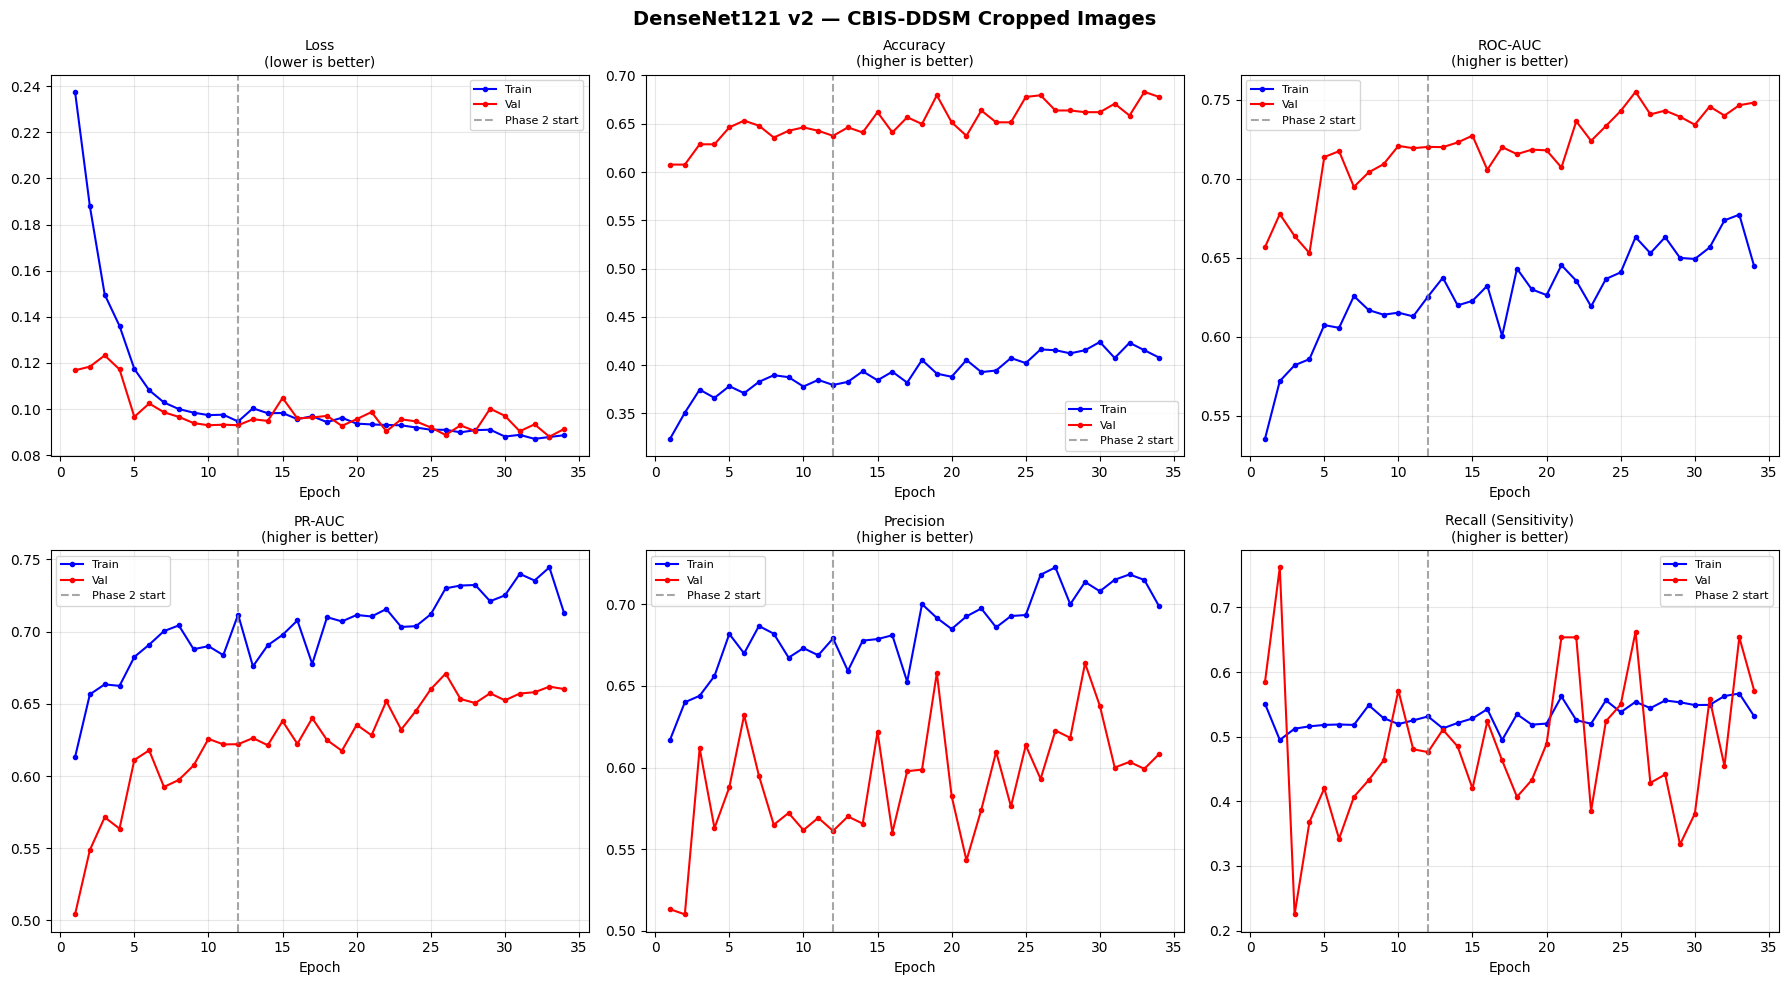

  Saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v2/training_history.png


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 ── Training history plots
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 7 — Plotting training history …")

def merge_histories(h1, h2):
    merged = {}
    keys = set(h1.history) | set(h2.history)
    for k in keys:
        merged[k] = list(h1.history.get(k, [])) + list(h2.history.get(k, []))
    return merged

history = merge_histories(history_p1, history_p2)
p1_end  = len(history_p1.history["loss"])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("DenseNet121 v2 — CBIS-DDSM Cropped Images",
             fontsize=14, fontweight="bold")

metrics_to_plot = [
    ("loss",      "val_loss",      "Loss",                  "lower is better"),
    ("accuracy",  "val_accuracy",  "Accuracy",              "higher is better"),
    ("auc",       "val_auc",       "ROC-AUC",               "higher is better"),
    ("pr_auc",    "val_pr_auc",    "PR-AUC",                "higher is better"),
    ("precision", "val_precision", "Precision",             "higher is better"),
    ("recall",    "val_recall",    "Recall (Sensitivity)",  "higher is better"),
]

for ax, (tk, vk, title, note) in zip(axes.flat, metrics_to_plot):
    if tk not in history or vk not in history:
        continue
    epochs = range(1, len(history[tk]) + 1)
    ax.plot(epochs, history[tk], "b-o", ms=3, label="Train")
    ax.plot(epochs, history[vk], "r-o", ms=3, label="Val")
    ax.axvline(p1_end, color="gray", linestyle="--", alpha=0.7,
               label="Phase 2 start")
    ax.set_title(f"{title}\n({note})", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = str(SAVE_DIR / "training_history.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → {plot_path}")


▶  STEP 8 — Evaluating on TEST set (with TTA) …

21/21 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step
  TTA view 1/8 …
  TTA view 2/8 …
  TTA view 3/8 …
  TTA view 4/8 …
  TTA view 5/8 …
  TTA view 6/8 …
  TTA view 7/8 …
  TTA view 8/8 …

  ──────────────────────────────────────────────────
  ROC-AUC  (no-TTA) : 0.7645
  ROC-AUC  ( +TTA ) : 0.7750    ← official
  PR-AUC   ( +TTA ) : 0.7259
  ──────────────────────────────────────────────────

  Threshold = 0.50  (default)
    Accuracy 0.7032  Sens 0.7721  Spec 0.6516  F1 0.6902  PPV 0.6241  NPV 0.7924
    TP=166  TN=187  FP=100  FN=49

  Threshold = Youden  (0.501)
    Accuracy 0.7032  Sens 0.7721  Spec 0.6516  F1 0.6902  PPV 0.6241  NPV 0.7924
    TP=166  TN=187  FP=100  FN=49

  Threshold = F1-max  (0.469)
    Accuracy 0.6673  Sens 0.8884  Spec 0.5017  F1 0.6958  PPV 0.5719  NPV 0.8571
    TP=191  TN=144  FP=143  FN=24

  ╔══════════════════════════════════════════════════════════════╗
  ║  BEST RESULT  (threshold = F1-max  (0.469))
  ╚══════════

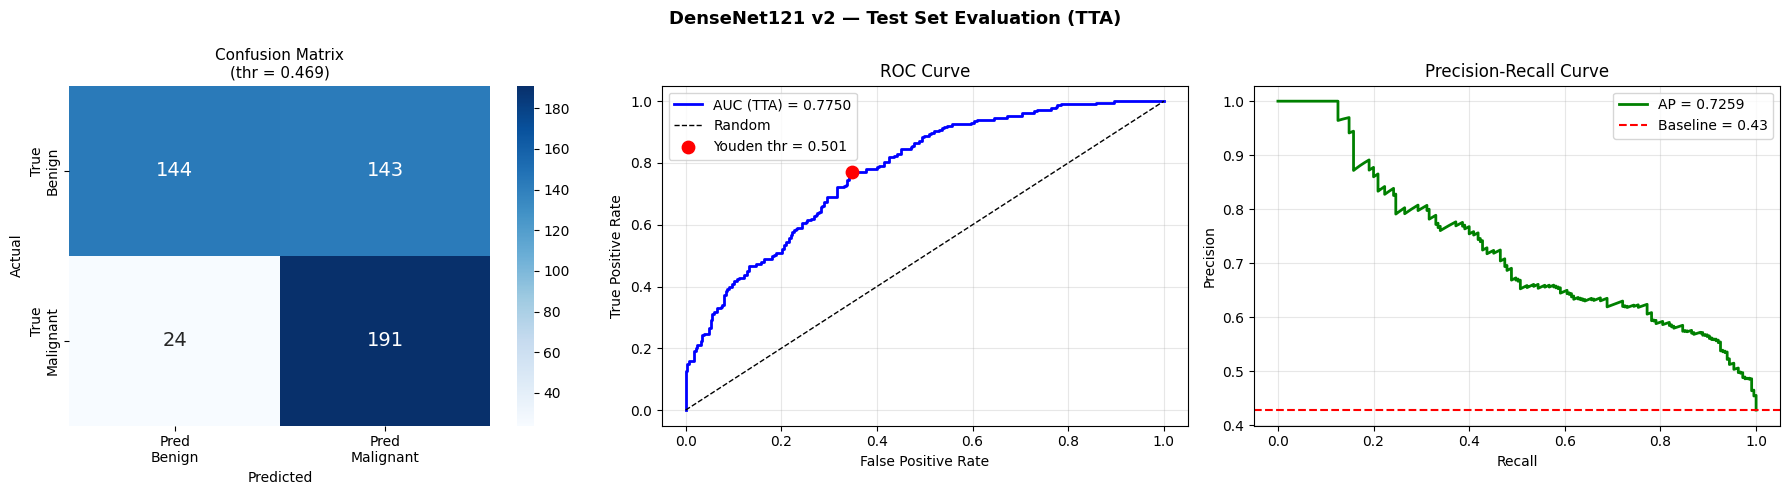

  Saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v2/evaluation_plots.png


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 ── Evaluate on TEST set + Test-Time Augmentation (TTA)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 8 — Evaluating on TEST set (with TTA) …\n")

model.load_weights(phase2_ckpt)

# ── (a) standard prediction ──────────────────────────────────────────────
y_prob_std = model.predict(test_ds, verbose=1).flatten()

# ── (b) TTA prediction — average over TTA_STEPS deterministic views ──────
tta_probs = np.zeros_like(y_prob_std, dtype=np.float64)
for t in range(TTA_STEPS):
    print(f"  TTA view {t+1}/{TTA_STEPS} …")
    ds_tta = make_tta_ds(TEST_DIR, tf.constant(t, dtype=tf.int32))
    tta_probs += model.predict(ds_tta, verbose=0).flatten()
tta_probs /= TTA_STEPS

y_true = np.array(test_labels, dtype=int)

# Use TTA probs as the official prediction
y_prob = tta_probs

# ── threshold optimization ───────────────────────────────────────────────
fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
youden_j = tpr - fpr
thr_youden = float(thr_roc[np.argmax(youden_j)])

pr_p, pr_r, thr_pr = precision_recall_curve(y_true, y_prob)
f1s = 2 * pr_p * pr_r / (pr_p + pr_r + 1e-9)
thr_f1 = float(thr_pr[np.argmax(f1s[:-1])]) if len(thr_pr) > 0 else 0.5

thresholds = {
    "0.50  (default)"   : 0.5,
    f"Youden  ({thr_youden:.3f})" : thr_youden,
    f"F1-max  ({thr_f1:.3f})"     : thr_f1,
}

# ── compute metrics for each threshold ───────────────────────────────────
def metrics_at(thr):
    yp = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, yp)
    tn, fp, fn, tp = cm.ravel()
    acc  = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    f1   = 2 * ppv * sens / (ppv + sens) if (ppv + sens) > 0 else 0.0
    return dict(thr=thr, acc=acc, sens=sens, spec=spec,
                ppv=ppv, npv=npv, f1=f1, tp=int(tp), tn=int(tn),
                fp=int(fp), fn=int(fn))

auc_roc_std = roc_auc_score(y_true, y_prob_std)
auc_roc     = roc_auc_score(y_true, y_prob)
ap          = average_precision_score(y_true, y_prob)

print("\n  ──────────────────────────────────────────────────")
print(f"  ROC-AUC  (no-TTA) : {auc_roc_std:.4f}")
print(f"  ROC-AUC  ( +TTA ) : {auc_roc:.4f}    ← official")
print(f"  PR-AUC   ( +TTA ) : {ap:.4f}")
print("  ──────────────────────────────────────────────────\n")

best = None
rows = []
for name, thr in thresholds.items():
    m = metrics_at(thr)
    rows.append({"threshold": name, **m})
    print(f"  Threshold = {name}")
    print(f"    Accuracy {m['acc']:.4f}  Sens {m['sens']:.4f}  "
          f"Spec {m['spec']:.4f}  F1 {m['f1']:.4f}  PPV {m['ppv']:.4f}  NPV {m['npv']:.4f}")
    print(f"    TP={m['tp']}  TN={m['tn']}  FP={m['fp']}  FN={m['fn']}\n")
    if best is None or m["f1"] > best["f1"]:
        best = {"name": name, **m}

thr_metrics_df = pd.DataFrame(rows)
thr_metrics_df.to_csv(SAVE_DIR / "threshold_metrics.csv", index=False)

# ── classification report at the F1-best threshold ───────────────────────
print("  ╔══════════════════════════════════════════════════════════════╗")
print(f"  ║  BEST RESULT  (threshold = {best['name']})")
print("  ╚══════════════════════════════════════════════════════════════╝")
y_pred_best = (y_prob >= best["thr"]).astype(int)
print("  " + classification_report(
    y_true, y_pred_best, target_names=["benign", "malignant"]
).replace("\n", "\n  "))

# ── plots: confusion matrix + ROC + PR curve ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DenseNet121 v2 — Test Set Evaluation (TTA)",
             fontsize=13, fontweight="bold")

cm = confusion_matrix(y_true, y_pred_best)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred\nBenign", "Pred\nMalignant"],
    yticklabels=["True\nBenign", "True\nMalignant"],
    ax=axes[0], annot_kws={"size": 14},
)
axes[0].set_title(f"Confusion Matrix\n(thr = {best['thr']:.3f})", fontsize=11)
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

axes[1].plot(fpr, tpr, "b-", lw=2, label=f"AUC (TTA) = {auc_roc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
opt_idx = int(np.argmax(youden_j))
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], color="red", s=80, zorder=5,
                label=f"Youden thr = {thr_youden:.3f}")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(pr_r, pr_p, "g-", lw=2, label=f"AP = {ap:.4f}")
axes[2].axhline(y_true.mean(), color="r", linestyle="--",
                label=f"Baseline = {y_true.mean():.2f}")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
eval_plot_path = str(SAVE_DIR / "evaluation_plots.png")
plt.savefig(eval_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → {eval_plot_path}")


▶  STEP 9 — Grad-CAM visualisation …



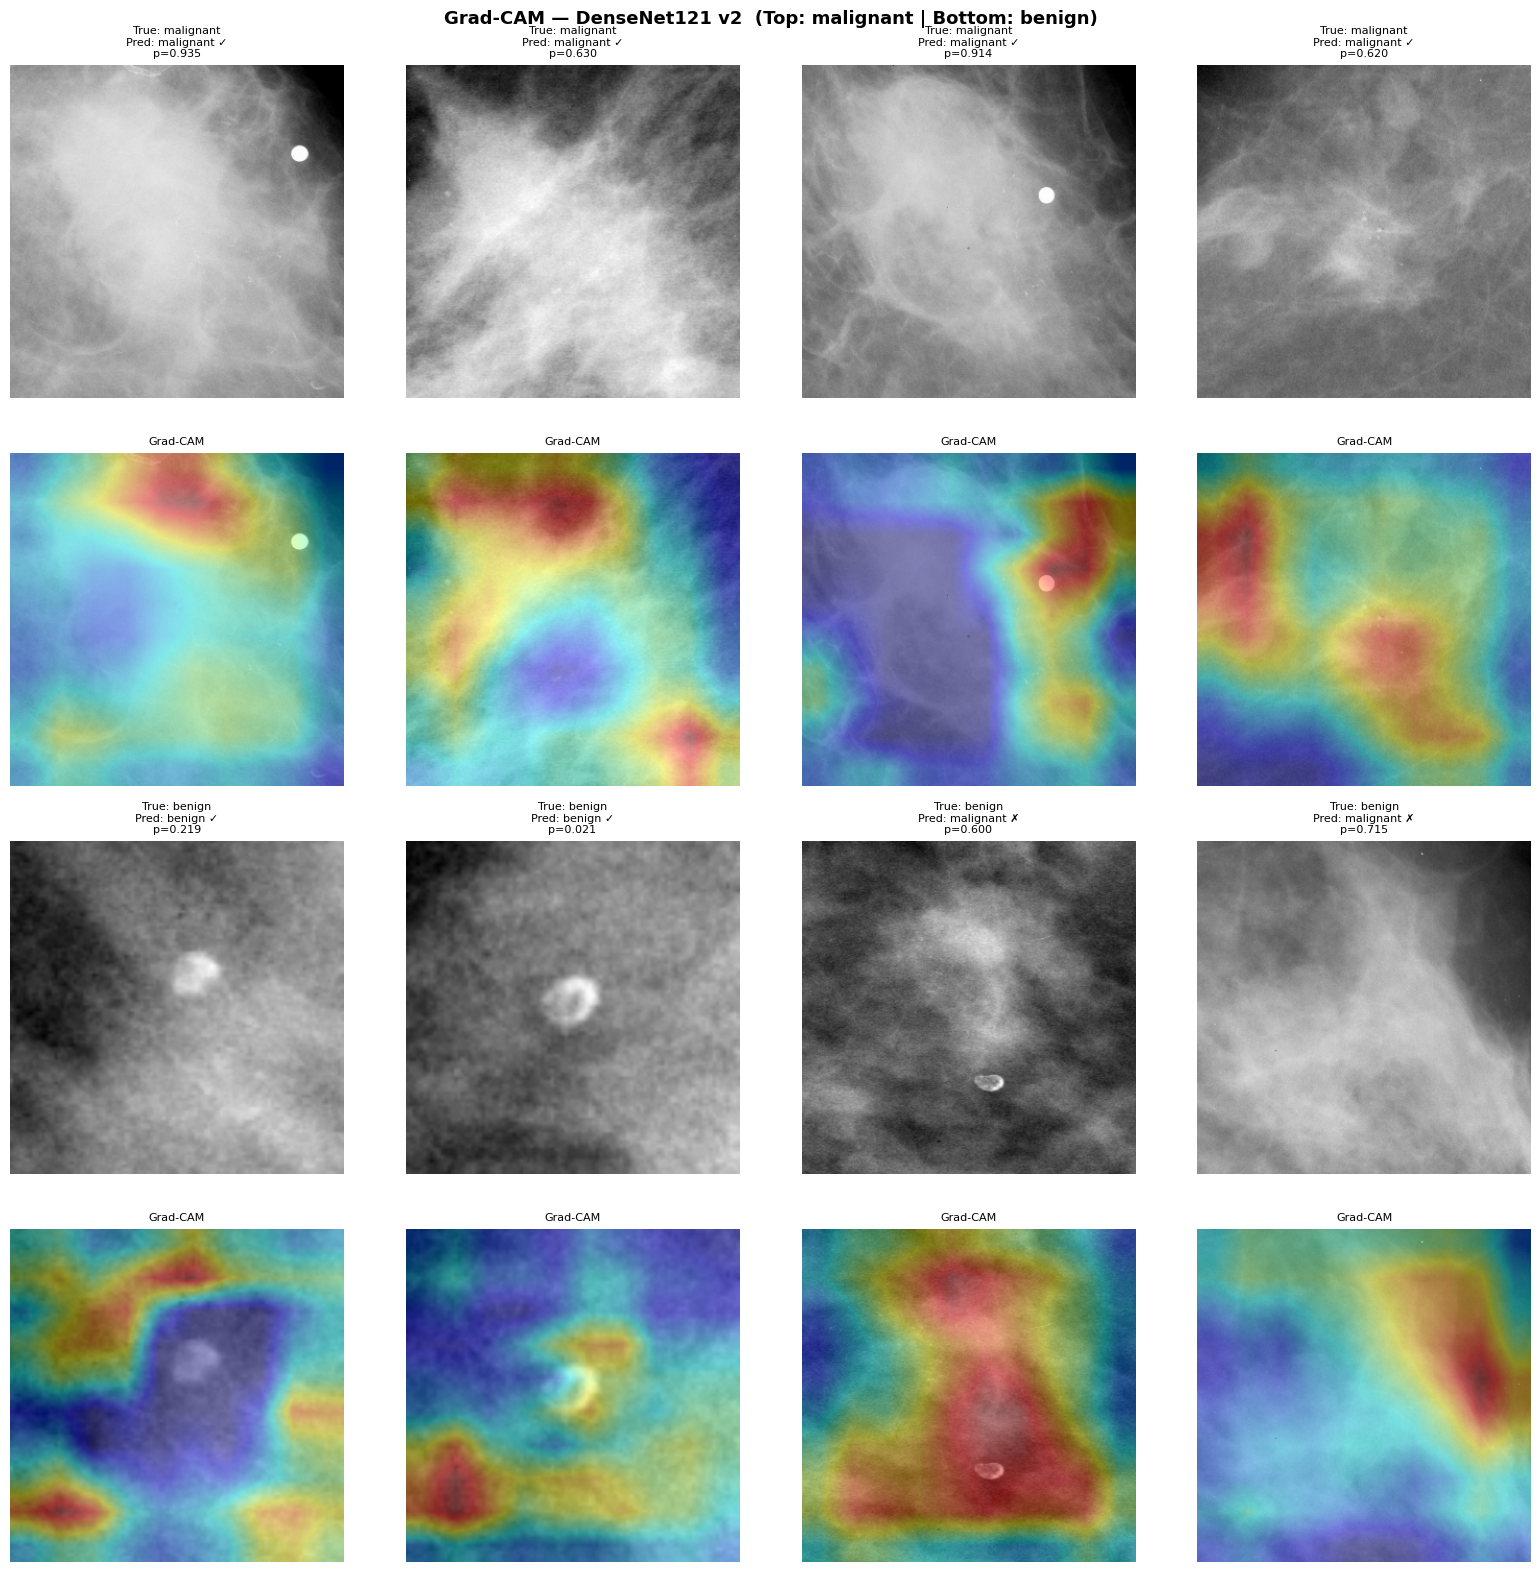

  Saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v2/gradcam_visualisation.png


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 ── Grad-CAM visualisation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 9 — Grad-CAM visualisation …\n")

LAST_CONV = "conv5_block16_2_conv"

def make_gradcam(img_array, target_model, last_conv=LAST_CONV):
    grad_model = Model(
        inputs  = target_model.inputs,
        outputs = [target_model.get_layer(last_conv).output, target_model.output],
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(tf.cast(img_array, tf.float32))
        loss = preds[:, 0]
    grads        = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out0    = conv_out[0]
    heatmap      = conv_out0 @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    h_u8   = np.uint8(255 * heatmap)
    h_col  = cv2.applyColorMap(cv2.resize(h_u8, (IMG_SIZE, IMG_SIZE)), cv2.COLORMAP_JET)
    h_col  = cv2.cvtColor(h_col, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img, 1 - alpha, h_col, alpha, 0), img

# pick 4 malignant + 4 benign
test_mal = [p for p, l in zip(test_paths, test_labels) if l == 1][:4]
test_ben = [p for p, l in zip(test_paths, test_labels) if l == 0][:4]
samples  = test_mal + test_ben
lbls     = [1] * 4 + [0] * 4

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle("Grad-CAM — DenseNet121 v2  (Top: malignant | Bottom: benign)",
             fontsize=13, fontweight="bold")

for col, (img_path, true_lbl) in enumerate(zip(samples, lbls)):
    raw   = tf.io.read_file(img_path)
    img_t = tf.image.decode_jpeg(raw, channels=3)
    img_t = tf.image.resize(img_t, [RESIZE_SIZE, RESIZE_SIZE])
    img_n = img_t.numpy().astype(np.uint8)
    img_n = apply_clahe(img_n)
    off   = (RESIZE_SIZE - IMG_SIZE) // 2
    img_n = img_n[off:off + IMG_SIZE, off:off + IMG_SIZE, :]
    img_p = preprocess_input(img_n.astype(np.float32))
    img_b = img_p[np.newaxis, ...]

    pred  = float(model.predict(img_b, verbose=0)[0][0])
    pname = "malignant" if pred >= best["thr"] else "benign"
    tname = "malignant" if true_lbl == 1 else "benign"
    mark  = "✓" if pname == tname else "✗"

    hm = make_gradcam(img_b, model)
    gcam, orig = overlay(img_path, hm)

    row_top = 0 if col < 4 else 2
    c       = col % 4
    axes[row_top, c].imshow(orig)
    axes[row_top, c].set_title(
        f"True: {tname}\nPred: {pname} {mark}\np={pred:.3f}", fontsize=8)
    axes[row_top, c].axis("off")
    axes[row_top + 1, c].imshow(gcam)
    axes[row_top + 1, c].set_title("Grad-CAM", fontsize=8)
    axes[row_top + 1, c].axis("off")

plt.tight_layout()
gradcam_path = str(SAVE_DIR / "gradcam_visualisation.png")
plt.savefig(gradcam_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → {gradcam_path}")

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 13 ── Save results summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 10 — Saving results summary …")

results = {
    "model"             : "DenseNet121_v2",
    "dataset"           : "CBIS-DDSM cropped images",
    "img_size"          : IMG_SIZE,
    "batch_size"        : BATCH_SIZE,
    "phase1_epochs"     : len(history_p1.history["loss"]),
    "phase2_epochs"     : len(history_p2.history["loss"]),
    "tta_steps"         : TTA_STEPS,
    "best_threshold"    : round(float(best["thr"]), 4),
    "threshold_strategy": best["name"],
    "test_auc_roc_no_tta": round(auc_roc_std, 4),
    "test_auc_roc_tta"  : round(auc_roc,     4),
    "test_pr_auc_tta"   : round(ap,          4),
    "test_accuracy"     : round(best["acc"], 4),
    "test_f1"           : round(best["f1"],  4),
    "test_precision"    : round(best["ppv"], 4),
    "test_recall_sensitivity": round(best["sens"], 4),
    "test_specificity"  : round(best["spec"], 4),
    "test_npv"          : round(best["npv"], 4),
    "TP": int(best["tp"]), "TN": int(best["tn"]),
    "FP": int(best["fp"]), "FN": int(best["fn"]),
}

results_df = pd.DataFrame([results]).T
results_df.columns = ["Value"]
results_df.to_csv(SAVE_DIR / "results_summary.csv")
print(results_df.to_string())

# ── Compare against the previous (v1) result ─────────────────────────────
prev = {
    "test_accuracy": 0.6873, "test_auc_roc": 0.7622, "test_f1": 0.6456,
    "test_precision": 0.6272, "test_recall_sensitivity": 0.6651,
    "test_specificity": 0.7038, "test_npv": 0.7372,
}
rows = []
for k, v_prev in prev.items():
    v_now  = results.get(k.replace("test_auc_roc", "test_auc_roc_tta"))
    if v_now is None:
        v_now = results.get(k)
    delta  = v_now - v_prev
    arrow  = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    rows.append({"metric": k, "v1 (prev)": v_prev, "v2 (now)": v_now,
                  "Δ": round(delta, 4), "": arrow})

print("\n  ─── COMPARISON vs. PREVIOUS RESULT ──────────────────────────")
print(pd.DataFrame(rows).to_string(index=False))

print("\n" + "=" * 70)
print("  ALL FILES SAVED TO:")
print(f"  {SAVE_DIR}")
print("")
print("  densenet121_breast_cancer_v2.keras  ← full model")
print("  phase1_best.weights.h5              ← best phase-1 weights")
print("  phase2_best.weights.h5              ← best phase-2 weights")
print("  training_history.png                ← curves")
print("  evaluation_plots.png                ← CM + ROC + PR")
print("  gradcam_visualisation.png           ← attention maps")
print("  phase1_history.csv / phase2_history.csv")
print("  threshold_metrics.csv               ← metrics at 0.5/Youden/F1-max")
print("  results_summary.csv                 ← final headline metrics")
print("=" * 70)
print("  ✅  Training & evaluation complete!")
print("=" * 70)


▶  STEP 10 — Saving results summary …
                                            Value
model                              DenseNet121_v2
dataset                  CBIS-DDSM cropped images
img_size                                      320
batch_size                                     24
phase1_epochs                                  12
phase2_epochs                                  22
tta_steps                                       8
best_threshold                             0.4693
threshold_strategy                F1-max  (0.469)
test_auc_roc_no_tta                        0.7645
test_auc_roc_tta                            0.775
test_pr_auc_tta                            0.7259
test_accuracy                              0.6673
test_f1                                    0.6958
test_precision                             0.5719
test_recall_sensitivity                    0.8884
test_specificity                           0.5017
test_npv                                   0.8571
TP         

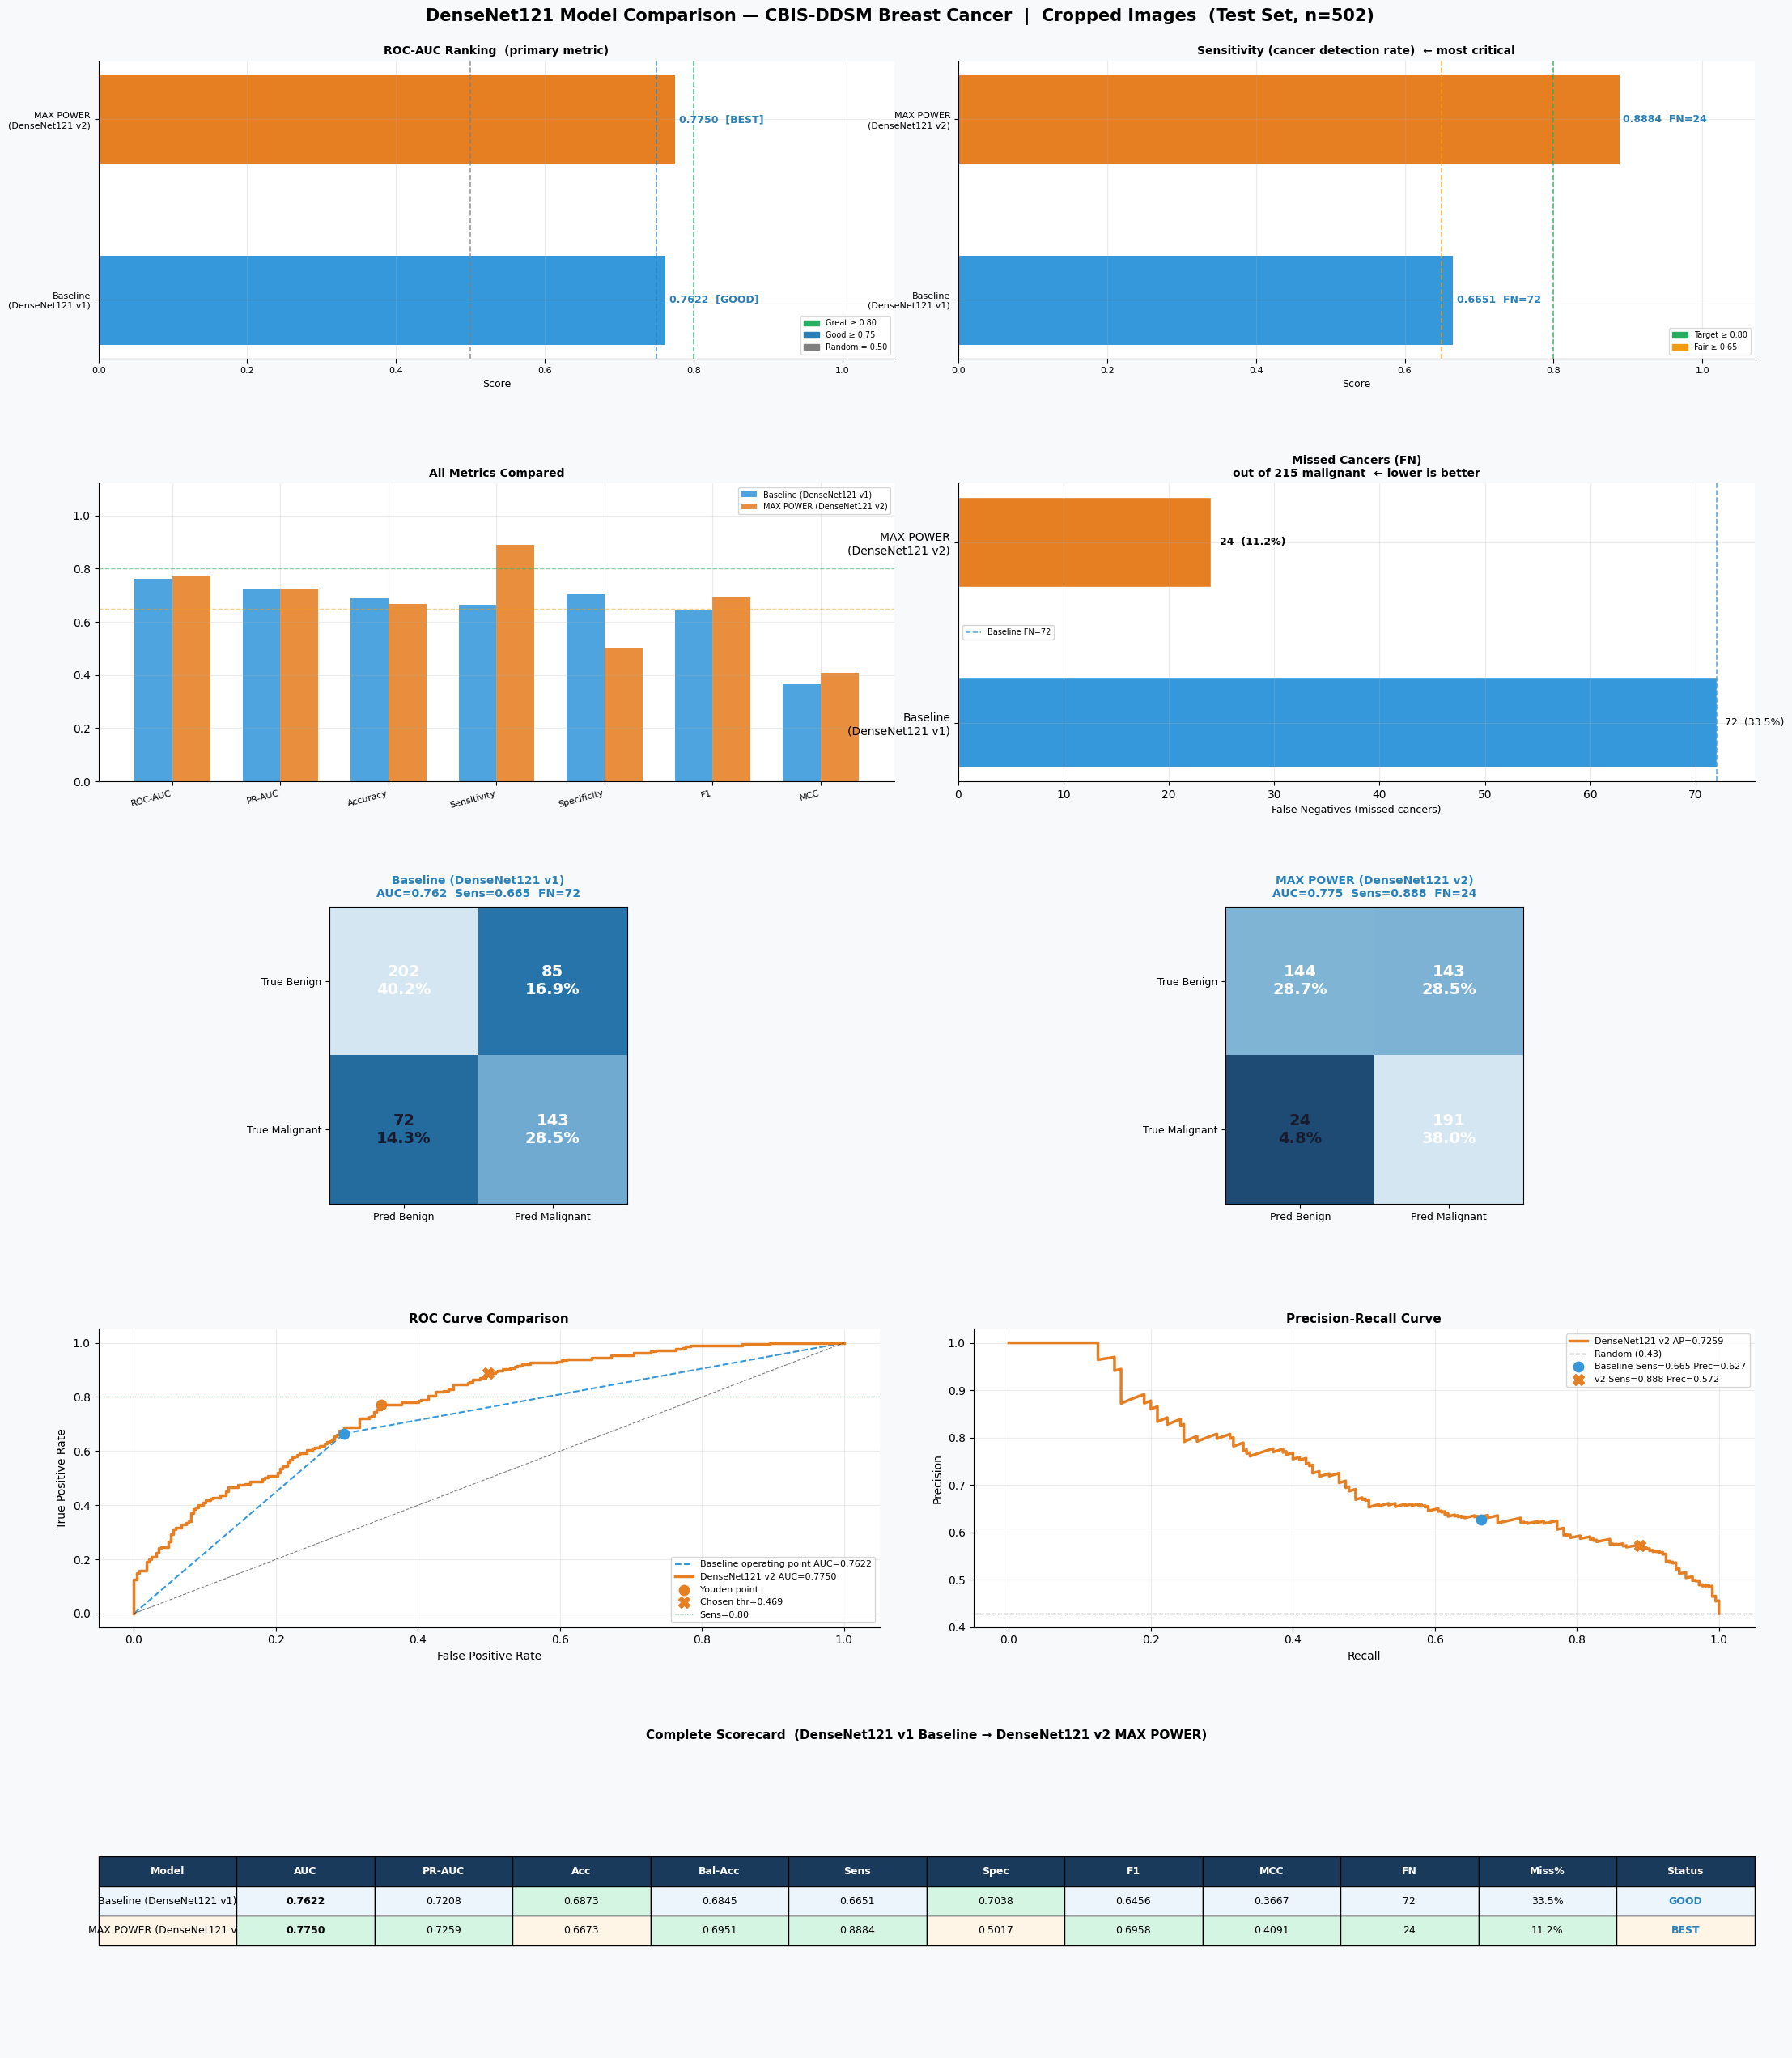

✅ DenseNet121 comparison dashboard saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_inceptionv3/densenet121_comparison_dashboard.png


In [19]:
# ============================================================================
# CELL 14 / 16 - DenseNet121 Comparison Dashboard
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_curve, precision_recall_curve

# ── Safety check ─────────────────────────────────────────────────────────────
_required = ["y_true", "y_prob", "best", "auc_roc", "ap", "SAVE_DIR"]
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        "Run the DenseNet121 evaluation + results cells first. "
        f"Missing variables: {_missing}"
    )

# ── Helpers ─────────────────────────────────────────────────────────────────
def status_color(auc):
    if auc >= 0.80:
        return "#27AE60"
    if auc >= 0.75:
        return "#2980B9"
    if auc >= 0.65:
        return "#F39C12"
    return "#E74C3C"

def status_label(auc):
    if auc >= 0.80:
        return "GREAT"
    if auc >= 0.75:
        return "GOOD"
    if auc >= 0.65:
        return "FAIR"
    return "FAILED"

def safe_mcc(tp, tn, fp, fn):
    denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return 0.0 if denom == 0 else ((tp * tn) - (fp * fn)) / denom

def clean_ax(ax):
    ax.grid(alpha=0.25)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

# ── Current DenseNet121 v2 metrics from notebook ─────────────────────────────
_tp = int(best["tp"])
_tn = int(best["tn"])
_fp = int(best["fp"])
_fn = int(best["fn"])

_prec = float(best.get("ppv", best.get("prec", _tp / (_tp + _fp))))
_sens = float(best["sens"])
_spec = float(best["spec"])
_acc  = float(best["acc"])
_f1   = float(best["f1"])
_thr  = float(best["thr"])
_mcc  = safe_mcc(_tp, _tn, _fp, _fn)

# ── Model registry ───────────────────────────────────────────────────────────
# Baseline DenseNet121 v1 values from uploaded 6-model final comparison image:
# AUC=.7622, PR-AUC=.7208, Acc=.6873, Sens=.6651, Spec=.7038,
# F1=.6456, MCC=.3667, TN=202, FP=85, FN=72, TP=143.
_b_tp, _b_tn, _b_fp, _b_fn = 143, 202, 85, 72

MODELS = {
    "Baseline\n(DenseNet121 v1)": dict(
        color="#3498DB",
        auc=0.7622,
        pr_auc=0.7208,
        acc=0.6873,
        sens=0.6651,
        spec=0.7038,
        prec=_b_tp / (_b_tp + _b_fp),
        f1=0.6456,
        mcc=0.3667,
        fn=_b_fn,
        tp=_b_tp,
        tn=_b_tn,
        fp=_b_fp,
        n_mal=_b_tp + _b_fn,
        thr=None,
    ),
    "MAX POWER\n(DenseNet121 v2)": dict(
        color="#E67E22",
        auc=float(auc_roc),
        pr_auc=float(ap),
        acc=_acc,
        sens=_sens,
        spec=_spec,
        prec=_prec,
        f1=_f1,
        mcc=_mcc,
        fn=_fn,
        tp=_tp,
        tn=_tn,
        fp=_fp,
        n_mal=_tp + _fn,
        thr=_thr,
    ),
}

names = list(MODELS.keys())
colors = [MODELS[n]["color"] for n in names]
best_auc_name = max(names, key=lambda n: MODELS[n]["auc"])

def display_status(nm):
    return "BEST" if nm == best_auc_name else status_label(MODELS[nm]["auc"])

n_test_total = _tp + _tn + _fp + _fn
n_malignant = _tp + _fn

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor="#F8F9FA")
fig.suptitle(
    f"DenseNet121 Model Comparison — CBIS-DDSM Breast Cancer  |  Cropped Images"
    f"  (Test Set, n={n_test_total})",
    fontsize=15,
    fontweight="bold",
    y=0.99,
)

outer = gridspec.GridSpec(
    5, 1, figure=fig,
    hspace=0.42,
    top=0.965,
    bottom=0.02,
    left=0.05,
    right=0.98,
)

# ── ROW 0: AUC ranking | sensitivity ranking ────────────────────────────────
row0 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], wspace=0.08)
ax_auc = fig.add_subplot(row0[0])
ax_sens = fig.add_subplot(row0[1])

rank_auc = sorted(names, key=lambda n: MODELS[n]["auc"], reverse=True)
rank_sens = sorted(names, key=lambda n: MODELS[n]["sens"], reverse=True)

for ax, metric, order, title, reflines in [
    (
        ax_auc,
        "auc",
        rank_auc,
        "ROC-AUC Ranking  (primary metric)",
        [
            (0.80, "#27AE60", "Great ≥ 0.80"),
            (0.75, "#2980B9", "Good ≥ 0.75"),
            (0.50, "gray", "Random = 0.50"),
        ],
    ),
    (
        ax_sens,
        "sens",
        rank_sens,
        "Sensitivity (cancer detection rate)  ← most critical",
        [
            (0.80, "#27AE60", "Target ≥ 0.80"),
            (0.65, "#F39C12", "Fair ≥ 0.65"),
        ],
    ),
]:
    vals = [MODELS[n][metric] for n in order]
    cols = [MODELS[n]["color"] for n in order]

    bars = ax.barh(order, vals, color=cols, height=0.5, edgecolor="white", linewidth=0.7)
    ax.invert_yaxis()

    for bar, val, nm in zip(bars, vals, order):
        sc = status_color(MODELS[nm]["auc"])
        label = (
            f"{val:.4f}  [{display_status(nm)}]"
            if metric == "auc"
            else f"{val:.4f}  FN={MODELS[nm]['fn']}"
        )
        ax.text(
            val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=9,
            color=sc,
            fontweight="bold",
        )

    for xv, c, lbl in reflines:
        ax.axvline(xv, color=c, ls="--", lw=1.2, alpha=0.8)

    ax.set_xlim(0, 1.07)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.tick_params(labelsize=8)
    ax.set_xlabel("Score", fontsize=9)
    clean_ax(ax)

    handles = [mpatches.Patch(color=c, label=lbl) for _, c, lbl in reflines]
    ax.legend(handles=handles, fontsize=7, loc="lower right", framealpha=0.7)

# ── ROW 1: all metrics | missed cancers ─────────────────────────────────────
row1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], wspace=0.08)
ax_multi = fig.add_subplot(row1[0])
ax_fn = fig.add_subplot(row1[1])

MK = ["auc", "pr_auc", "acc", "sens", "spec", "f1", "mcc"]
MLBL = ["ROC-AUC", "PR-AUC", "Accuracy", "Sensitivity", "Specificity", "F1", "MCC"]

x = np.arange(len(MK))
bw = 0.35

for i, nm in enumerate(names):
    vals = [MODELS[nm][k] for k in MK]
    ax_multi.bar(
        x + (i - 0.5) * bw,
        vals,
        bw,
        color=MODELS[nm]["color"],
        alpha=0.88,
        label=nm.replace("\n", " "),
    )

ax_multi.set_xticks(x)
ax_multi.set_xticklabels(MLBL, rotation=15, ha="right", fontsize=8)
ax_multi.set_ylim(0, 1.12)
ax_multi.set_title("All Metrics Compared", fontsize=10, fontweight="bold")
ax_multi.legend(fontsize=7, loc="upper right")
ax_multi.axhline(0.80, color="#27AE60", ls="--", lw=1, alpha=0.5)
ax_multi.axhline(0.65, color="#F39C12", ls="--", lw=1, alpha=0.5)
clean_ax(ax_multi)

rank_fn = sorted(names, key=lambda n: MODELS[n]["fn"])
fn_vals = [MODELS[n]["fn"] for n in rank_fn]
fn_cols = [MODELS[n]["color"] for n in rank_fn]

fn_bars = ax_fn.barh(rank_fn, fn_vals, color=fn_cols, height=0.5, edgecolor="white")
ax_fn.invert_yaxis()

for bar, fn, nm in zip(fn_bars, fn_vals, rank_fn):
    n_mal = MODELS[nm]["n_mal"]
    ax_fn.text(
        fn + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{fn}  ({fn / n_mal * 100:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold" if nm == "MAX POWER\n(DenseNet121 v2)" else "normal",
    )

ax_fn.axvline(
    _b_fn,
    color=MODELS["Baseline\n(DenseNet121 v1)"]["color"],
    ls="--",
    lw=1.2,
    alpha=0.8,
    label=f"Baseline FN={_b_fn}",
)
ax_fn.set_title(
    f"Missed Cancers (FN)\nout of {n_malignant} malignant  ← lower is better",
    fontsize=10,
    fontweight="bold",
)
ax_fn.set_xlabel("False Negatives (missed cancers)", fontsize=9)
ax_fn.legend(fontsize=7)
clean_ax(ax_fn)

# ── ROW 2: confusion matrices ───────────────────────────────────────────────
row2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[2], wspace=0.18)
cmap_cm = LinearSegmentedColormap.from_list(
    "cm_dashboard",
    ["#1A3A5C", "#2980B9", "#D4E6F1"],
)

for i, nm in enumerate(names):
    d = MODELS[nm]
    cm_arr = np.array([[d["tn"], d["fp"]], [d["fn"], d["tp"]]])
    n = cm_arr.sum()

    ax = fig.add_subplot(row2[i])
    ax.imshow(cm_arr, cmap=cmap_cm, vmin=0, vmax=max(cm_arr.max(), 1))

    for r in range(2):
        for c in range(2):
            val = cm_arr[r, c]
            ax.text(
                c,
                r,
                f"{val}\n{val / n * 100:.1f}%",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color="white" if val > cm_arr.max() * 0.4 else "#1A1A2E",
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Benign", "Pred Malignant"], fontsize=9)
    ax.set_yticklabels(["True Benign", "True Malignant"], fontsize=9)
    ax.set_title(
        f"{nm.replace(chr(10), ' ')}\n"
        f"AUC={d['auc']:.3f}  Sens={d['sens']:.3f}  FN={d['fn']}",
        fontsize=10,
        fontweight="bold",
        color=status_color(d["auc"]),
        pad=8,
    )

# ── ROW 3: ROC and PR curves ────────────────────────────────────────────────
row3 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[3], wspace=0.12)
ax_roc = fig.add_subplot(row3[0])
ax_pr = fig.add_subplot(row3[1])

y_true_dash = np.asarray(y_true).astype(int)
y_prob_dash = np.asarray(y_prob).astype(float)

fpr_new, tpr_new, thr_new = roc_curve(y_true_dash, y_prob_dash)
youden_idx = int(np.argmax(tpr_new - fpr_new))

pr_precision, pr_recall, _ = precision_recall_curve(y_true_dash, y_prob_dash)
random_pr = y_true_dash.mean()

b = MODELS["Baseline\n(DenseNet121 v1)"]
n = MODELS["MAX POWER\n(DenseNet121 v2)"]

# Baseline raw probabilities are not available from the image, so this is an
# operating-point proxy using the baseline confusion matrix.
ax_roc.plot(
    [0, 1 - b["spec"], 1],
    [0, b["sens"], 1],
    "--",
    color=b["color"],
    lw=1.5,
    label=f"Baseline operating point AUC={b['auc']:.4f}",
)
ax_roc.scatter(
    [1 - b["spec"]],
    [b["sens"]],
    color=b["color"],
    s=80,
    zorder=5,
)

ax_roc.plot(
    fpr_new,
    tpr_new,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"DenseNet121 v2 AUC={n['auc']:.4f}",
)
ax_roc.scatter(
    [fpr_new[youden_idx]],
    [tpr_new[youden_idx]],
    color=n["color"],
    s=80,
    zorder=5,
    label=f"Youden point",
)
ax_roc.scatter(
    [1 - n["spec"]],
    [n["sens"]],
    marker="X",
    color=n["color"],
    s=100,
    zorder=6,
    label=f"Chosen thr={n['thr']:.3f}",
)

ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax_roc.axhline(0.80, color="#27AE60", ls=":", lw=0.8, alpha=0.6, label="Sens=0.80")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve Comparison", fontsize=11, fontweight="bold")
ax_roc.legend(fontsize=8)
clean_ax(ax_roc)

ax_pr.plot(
    pr_recall,
    pr_precision,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"DenseNet121 v2 AP={n['pr_auc']:.4f}",
)
ax_pr.axhline(random_pr, color="gray", ls="--", lw=1, label=f"Random ({random_pr:.2f})")

ax_pr.scatter(
    [b["sens"]],
    [b["prec"]],
    color=b["color"],
    s=80,
    zorder=5,
    label=f"Baseline Sens={b['sens']:.3f} Prec={b['prec']:.3f}",
)
ax_pr.scatter(
    [n["sens"]],
    [n["prec"]],
    color=n["color"],
    marker="X",
    s=100,
    zorder=6,
    label=f"v2 Sens={n['sens']:.3f} Prec={n['prec']:.3f}",
)

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
ax_pr.legend(fontsize=8)
clean_ax(ax_pr)

# ── ROW 4: scorecard table ─────────────────────────────────────────────────
ax_tbl = fig.add_subplot(outer[4])
ax_tbl.axis("off")

COLS = [
    "Model",
    "AUC",
    "PR-AUC",
    "Acc",
    "Bal-Acc",
    "Sens",
    "Spec",
    "F1",
    "MCC",
    "FN",
    "Miss%",
    "Status",
]

rows_data = []
for nm in names:
    d = MODELS[nm]
    bal_acc = (d["sens"] + d["spec"]) / 2
    rows_data.append([
        nm.replace("\n", " "),
        f"{d['auc']:.4f}",
        f"{d['pr_auc']:.4f}",
        f"{d['acc']:.4f}",
        f"{bal_acc:.4f}",
        f"{d['sens']:.4f}",
        f"{d['spec']:.4f}",
        f"{d['f1']:.4f}",
        f"{d['mcc']:.4f}",
        str(d["fn"]),
        f"{d['fn'] / d['n_mal'] * 100:.1f}%",
        display_status(nm),
    ])

tbl = ax_tbl.table(cellText=rows_data, colLabels=COLS, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 2.2)

# Header
for j in range(len(COLS)):
    tbl[(0, j)].set_facecolor("#1A3A5C")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")

row_bg = ["#EBF5FB", "#FEF5E7"]
for i, nm in enumerate(names):
    sc = status_color(MODELS[nm]["auc"])
    for j in range(len(COLS)):
        cell = tbl[(i + 1, j)]
        cell.set_facecolor(row_bg[i])
        if j == 1:
            cell.set_text_props(fontweight="bold")
        if j == len(COLS) - 1:
            cell.set_text_props(color=sc, fontweight="bold")

# Highlight winners
higher_is_better = {1, 2, 3, 4, 5, 6, 7, 8}
lower_is_better = {9, 10}

for col_idx in range(1, len(COLS) - 1):
    raw = []
    for r in range(len(names)):
        txt = tbl[(r + 1, col_idx)].get_text().get_text().replace("%", "")
        raw.append(float(txt))

    if col_idx in higher_is_better:
        best_val = max(raw)
    elif col_idx in lower_is_better:
        best_val = min(raw)
    else:
        continue

    for r, val in enumerate(raw):
        if abs(val - best_val) < 1e-9:
            tbl[(r + 1, col_idx)].set_facecolor("#D5F5E3")

ax_tbl.set_title(
    "Complete Scorecard  (DenseNet121 v1 Baseline → DenseNet121 v2 MAX POWER)",
    fontsize=11,
    fontweight="bold",
    pad=12,
    y=1.0,
)

# ── Save ────────────────────────────────────────────────────────────────────
save_path = Path(SAVE_DIR) / "densenet121_comparison_dashboard.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.show()

print(f"✅ DenseNet121 comparison dashboard saved → {save_path}")